## Q1. Load Your Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")


Libraries loaded successfully.


## Q2. Load Your Dataset

In [2]:
df = pd.read_csv("../data/bhatbhateni_sales.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (18812, 11)


# Part A : Initial Dataset Inspection

## Q3a. What do the first five rows look like?

In [3]:
df.head()


,TransactionID,Date,CustomerID,CustomerName,Branch,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,TXN101590,2025-05-19,CUST1100,Sujan Shrestha,Pokhara - Lakeside,Bakery,Chocolate Cake Slice,2,171.29,342.58,Khalti
1,TXN103282,2025-03-07,CUST1005,Milan Lama,Butwal - Traffic Chowk,Personal Care,Dove Soap,3,149.59,448.77,eSewa
2,TXN103539,2025-10-05,CUST1130,Alina Rai,Bhaktapur - Suryabinayak,Apparel,Winter Jacket,4,2794.25,11177.00,Khalti
3,TXN102479,2025-11-12,CUST1057,Neha Karki,Kathmandu - New Road,Household,Surf Excel 1kg,4,399.62,1598.48,Cash
4,TXN104408,2025-10-09,CUST1005,Milan Lama,Butwal - Traffic Chowk,Beverages,Gorkha Beer (6-pack),2,281.01,562.02,eSewa


## Q3b. How many rows and columns does the dataset have?

In [4]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)


Number of rows: 18812
Number of columns: 11


## Q3c. What are the column names?

In [5]:
print("Column names:")
for column in df.columns:
    print(column)


Column names:
TransactionID
Date
CustomerID
CustomerName
Branch
ProductCategory
ProductName
Quantity
UnitPrice
TotalAmount
PaymentMethod


## Q4a. What are the data types of each column, and does anything need converting?

In [6]:
print(df.dtypes)

print("\nDataset information:")
df.info()


TransactionID          str
Date                   str
CustomerID             str
CustomerName           str
Branch                 str
ProductCategory        str
ProductName            str
Quantity             int64
UnitPrice          float64
TotalAmount        float64
PaymentMethod          str
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 18812 entries, 0 to 18811
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    18812 non-null  str    
 1   Date             18812 non-null  str    
 2   CustomerID       18812 non-null  str    
 3   CustomerName     18244 non-null  str    
 4   Branch           18812 non-null  str    
 5   ProductCategory  18530 non-null  str    
 6   ProductName      18812 non-null  str    
 7   Quantity         18812 non-null  int64  
 8   UnitPrice        18441 non-null  float64
 9   TotalAmount      18812 non-null  float64
 10  PaymentMetho

In [7]:
# Date should be converted to datetime for time-series analysis.
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Updated data types:")
print(df.dtypes)


Updated data types:
TransactionID                 str
Date               datetime64[us]
CustomerID                    str
CustomerName                  str
Branch                        str
ProductCategory               str
ProductName                   str
Quantity                    int64
UnitPrice                 float64
TotalAmount               float64
PaymentMethod                 str
dtype: object


## Q4b. What do the summary statistics of the numeric columns tell you?

In [8]:
df.describe()


,Date,Quantity,UnitPrice,TotalAmount
count,18812,18812.000000,18441.000000,18812.000000
mean,2025-07-27 15:38:09.517329,2.506804,728.803530,1819.990565
min,2025-01-01 00:00:00,1.000000,40.140000,40.610000
25%,2025-04-24 18:00:00,2.000000,240.160000,488.397500
50%,2025-08-31 00:00:00,3.000000,416.780000,989.000000
75%,2025-10-22 00:00:00,3.000000,848.320000,2142.545000
max,2025-12-31 00:00:00,4.000000,3499.280000,13997.120000
std,NaN,1.114328,766.346109,2241.968350


# Part B: Data Quality Assessment

## Q5a. Are there any missing values?

In [9]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
)

missing_summary


,Missing Count,Missing Percentage
CustomerName,568,3.02
PaymentMethod,468,2.49
UnitPrice,371,1.97
ProductCategory,282,1.50


## Q5b. Are there any fully duplicated rows?

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of fully duplicated rows:", duplicate_count)


Number of fully duplicated rows: 724


## Q5c. Distinguishing repeat line-items from true duplicate rows

In [11]:
transaction_repeats = (
    df.groupby("TransactionID")
      .size()
      .reset_index(name="LineItemCount")
      .query("LineItemCount > 1")
      .sort_values("LineItemCount", ascending=False)
)

print("Transactions containing multiple line-items:", len(transaction_repeats))
transaction_repeats.head(10)


Transactions containing multiple line-items: 4860


,TransactionID,LineItemCount
2095,TXN102095,7
5735,TXN105735,7
1347,TXN101347,7
3983,TXN103983,7
3822,TXN103822,7
3841,TXN103841,7
255,TXN100255,7
3448,TXN103448,7
759,TXN100759,7
4414,TXN104414,7


## Q5d. Are there illogical values?

In [12]:
valid_amount_rows = df[
    df["Quantity"].notna() &
    df["UnitPrice"].notna() &
    df["TotalAmount"].notna()
].copy()

valid_amount_rows["ExpectedTotal"] = (
    valid_amount_rows["Quantity"] * valid_amount_rows["UnitPrice"]
)

valid_amount_rows["AmountDifference"] = (
    valid_amount_rows["TotalAmount"] - valid_amount_rows["ExpectedTotal"]
)

amount_mismatch = valid_amount_rows[
    ~np.isclose(
        valid_amount_rows["TotalAmount"],
        valid_amount_rows["ExpectedTotal"],
        rtol=1e-5,
        atol=1e-2
    )
]

print("Rows checked:", len(valid_amount_rows))
print("Rows with TotalAmount mismatch:", len(amount_mismatch))

amount_mismatch.head()


Rows checked: 18441
Rows with TotalAmount mismatch: 0


,TransactionID,Date,CustomerID,CustomerName,Branch,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod,ExpectedTotal,AmountDifference


# Part C:Data Cleaning

## Q6a. Remove exact duplicate rows

In [13]:
rows_before_duplicates = len(df)

df_clean = df.drop_duplicates().copy()

rows_after_duplicates = len(df_clean)
duplicates_removed = rows_before_duplicates - rows_after_duplicates

print("Rows before removing duplicates:", rows_before_duplicates)
print("Rows after removing duplicates:", rows_after_duplicates)
print("Duplicates removed:", duplicates_removed)


Rows before removing duplicates: 18812
Rows after removing duplicates: 18088
Duplicates removed: 724


## Q6b. Verify duplicate removal

In [14]:
print("Duplicate rows before cleaning:", df.duplicated().sum())
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())


Duplicate rows before cleaning: 724
Duplicate rows after cleaning: 0


## Q7a. Handle missing `CustomerName`

In [15]:
df_clean["CustomerName"] = df_clean["CustomerName"].fillna("Unknown Customer")


## Q7b. Fill missing `ProductCategory` using `ProductName`

In [16]:
product_category_map = (
    df_clean.dropna(subset=["ProductName", "ProductCategory"])
            .drop_duplicates("ProductName")
            .set_index("ProductName")["ProductCategory"]
)

df_clean["ProductCategory"] = (
    df_clean["ProductCategory"]
    .fillna(df_clean["ProductName"].map(product_category_map))
    .fillna("Unknown")
)

print("Missing ProductCategory after filling:", df_clean["ProductCategory"].isnull().sum())


Missing ProductCategory after filling: 0


## Q7c. Impute missing `UnitPrice`

In [17]:
price_from_total = (
    df_clean["TotalAmount"] / df_clean["Quantity"]
).where(df_clean["Quantity"] > 0)

df_clean["UnitPrice"] = df_clean["UnitPrice"].fillna(price_from_total)

category_medians = df_clean.groupby("ProductCategory")["UnitPrice"].transform("median")

df_clean["UnitPrice"] = df_clean["UnitPrice"].fillna(category_medians)

df_clean["UnitPrice"] = df_clean["UnitPrice"].fillna(df_clean["UnitPrice"].median())

print("Missing UnitPrice after imputation:", df_clean["UnitPrice"].isnull().sum())


Missing UnitPrice after imputation: 0


## Q7d. Handle missing `PaymentMethod`

In [18]:
df_clean["PaymentMethod"] = df_clean["PaymentMethod"].fillna("Unknown")

print("Missing PaymentMethod after filling:", df_clean["PaymentMethod"].isnull().sum())


Missing PaymentMethod after filling: 0


## Q7e. Confirm that no missing values remain

In [19]:
remaining_missing = df_clean.isnull().sum()

print("Remaining missing values:")
print(remaining_missing)

print("\nTotal remaining missing values:", remaining_missing.sum())


Remaining missing values:
TransactionID      0
Date               0
CustomerID         0
CustomerName       0
Branch             0
ProductCategory    0
ProductName        0
Quantity           0
UnitPrice          0
TotalAmount        0
PaymentMethod      0
dtype: int64

Total remaining missing values: 0


# Part D: Data Cleaning & Feature Engineering

## Q8a. Convert `Date` and extract time features

In [20]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["MonthName"] = df_clean["Date"].dt.month_name()
df_clean["Day"] = df_clean["Date"].dt.day
df_clean["DayOfWeek"] = df_clean["Date"].dt.day_name()
df_clean["IsWeekend"] = df_clean["Date"].dt.dayofweek >= 5

print(df_clean[["Date", "Year", "Month", "MonthName", "DayOfWeek", "IsWeekend"]].head())


        Date  Year  Month MonthName  DayOfWeek  IsWeekend
0 2025-05-19  2025      5       May     Monday      False
1 2025-03-07  2025      3     March     Friday      False
2 2025-10-05  2025     10   October     Sunday       True
3 2025-11-12  2025     11  November  Wednesday      False
4 2025-10-09  2025     10   October   Thursday      False


## Q8b. Split `Branch` into a `City` column

In [21]:
df_clean["City"] = (
    df_clean["Branch"]
    .astype(str)
    .str.split(",", n=1)
    .str[0]
    .str.strip()
)

print(df_clean[["Branch", "City"]].drop_duplicates().head(20))


                      Branch                      City
0         Pokhara - Lakeside        Pokhara - Lakeside
1     Butwal - Traffic Chowk    Butwal - Traffic Chowk
2   Bhaktapur - Suryabinayak  Bhaktapur - Suryabinayak
3       Kathmandu - New Road      Kathmandu - New Road
12       Lalitpur - Pulchowk       Lalitpur - Pulchowk
14     Kathmandu - Kupondole     Kathmandu - Kupondole
21    Biratnagar - Main Road    Biratnagar - Main Road
88       Chitwan - Bharatpur       Chitwan - Bharatpur


## Q8c. Recompute or validate `TotalAmount`

In [22]:
df_clean["CalculatedTotalAmount"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

df_clean["AmountDifference"] = (
    df_clean["TotalAmount"] - df_clean["CalculatedTotalAmount"]
)

print(df_clean[
    ["Quantity", "UnitPrice", "TotalAmount", "CalculatedTotalAmount", "AmountDifference"]
].head())


   Quantity  UnitPrice  TotalAmount  CalculatedTotalAmount  AmountDifference
0         2     171.29       342.58                 342.58               0.0
1         3     149.59       448.77                 448.77               0.0
2         4    2794.25     11177.00               11177.00               0.0
3         4     399.62      1598.48                1598.48               0.0
4         2     281.01       562.02                 562.02               0.0


# Part E: Univariate Analysis

## Q9a. Distribution of transactions across product categories

ProductCategory
Grocery          3065
Personal Care    2246
Dairy            2217
Household        2212
Apparel          2188
Electronics      2186
Beverages        2179
Bakery           1795
Name: count, dtype: int64


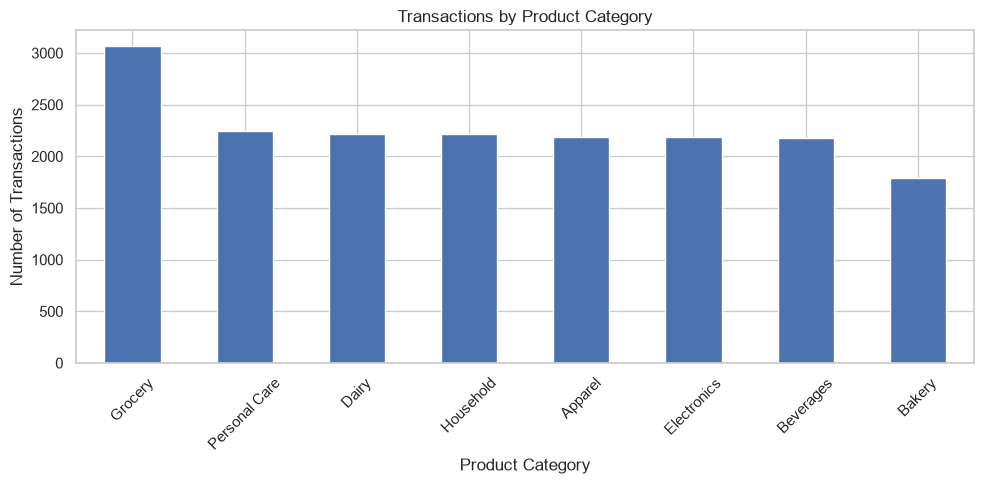

In [23]:
category_transactions = (
    df_clean["ProductCategory"]
    .value_counts()
    .sort_values(ascending=False)
)

print(category_transactions)

category_transactions.plot(kind="bar", figsize=(10, 5))
plt.title("Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Q9b. Distribution of transactions across branches

Branch
Kathmandu - Kupondole       3241
Bhaktapur - Suryabinayak    3050
Butwal - Traffic Chowk      2940
Kathmandu - New Road        2561
Lalitpur - Pulchowk         2337
Pokhara - Lakeside          1957
Chitwan - Bharatpur         1063
Biratnagar - Main Road       939
Name: count, dtype: int64


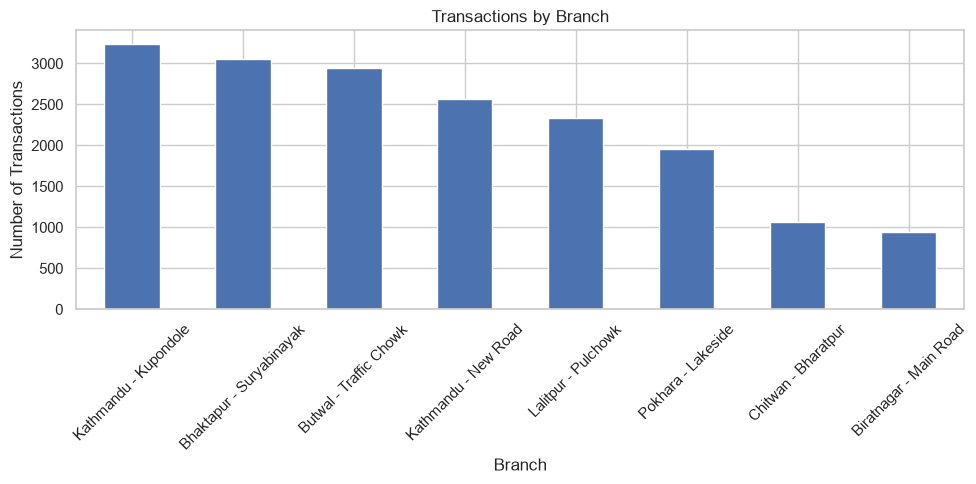

In [24]:
branch_transactions = df_clean["Branch"].value_counts()

print(branch_transactions)

branch_transactions.plot(kind="bar", figsize=(10, 5))
plt.title("Transactions by Branch")
plt.xlabel("Branch")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Q9c. Most commonly used payment method

In [25]:
payment_counts = df_clean["PaymentMethod"].value_counts()

print(payment_counts)
print("\nMost commonly used payment method:", payment_counts.idxmax())


PaymentMethod
Cash                 6218
eSewa                4951
Khalti               3795
Debit/Credit Card    1813
Bank Transfer         859
Unknown               452
Name: count, dtype: int64

Most commonly used payment method: Cash


## Q9d. Distribution of `TotalAmount`

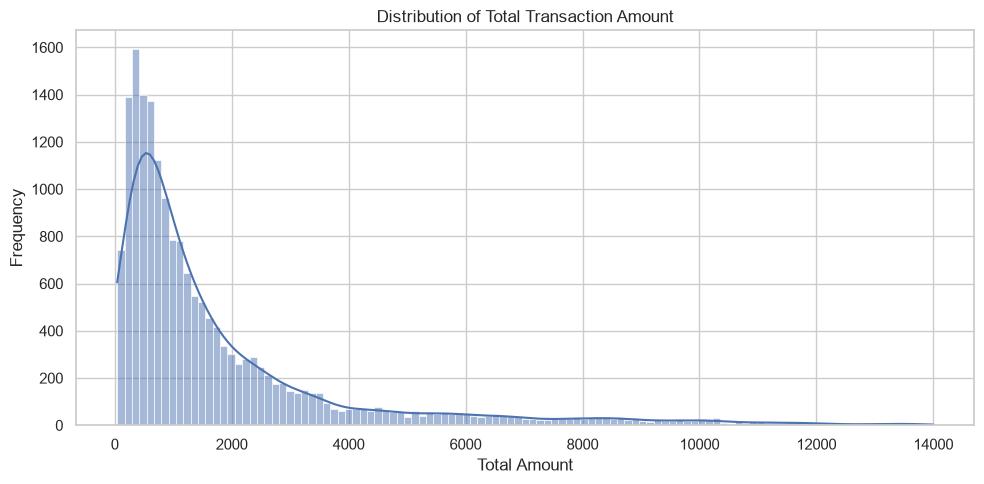

2.4642570960145744


In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["TotalAmount"], kde=True)
plt.title("Distribution of Total Transaction Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(df_clean["TotalAmount"].skew())


# Part F: Sales Trend Analysis

## Q10a. Month-over-month total revenue across 2025

    Year  Month  TotalAmount MonthLabel
0   2025      1   2047697.10    2025-01
1   2025      2   1813821.23    2025-02
2   2025      3   1887644.85    2025-03
3   2025      4   3088404.52    2025-04
4   2025      5   1804819.74    2025-05
5   2025      6   1875854.82    2025-06
6   2025      7   1881584.08    2025-07
7   2025      8   2096176.94    2025-08
8   2025      9   4630698.52    2025-09
9   2025     10   4717670.71    2025-10
10  2025     11   4647417.42    2025-11
11  2025     12   2512355.71    2025-12


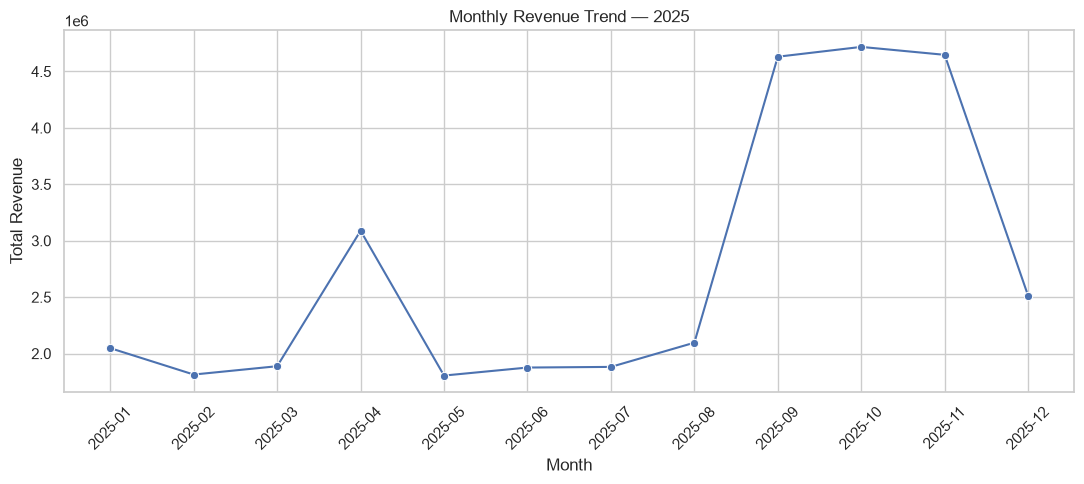

In [27]:
sales_2025 = df_clean[df_clean["Year"] == 2025].copy()

monthly_revenue = (
    sales_2025.groupby(["Year", "Month"])["TotalAmount"]
    .sum()
    .reset_index()
)

monthly_revenue["MonthLabel"] = (
    monthly_revenue["Year"].astype(str) + "-" +
    monthly_revenue["Month"].astype(str).str.zfill(2)
)

print(monthly_revenue)

plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly_revenue, x="MonthLabel", y="TotalAmount", marker="o")
plt.title("Monthly Revenue Trend — 2025")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Q10b. Weekend vs. weekday sales

IsWeekend
Weekday    23705495.89
Weekend     9298649.75
Name: TotalAmount, dtype: float64


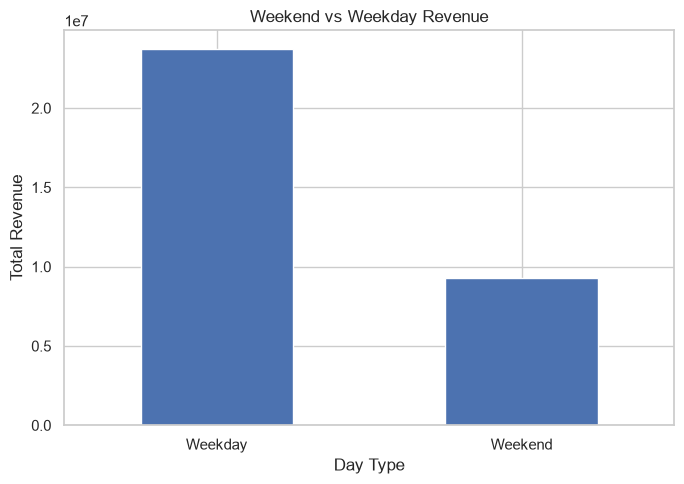

In [28]:
weekend_comparison = (
    df_clean.groupby("IsWeekend")["TotalAmount"]
    .sum()
    .rename(index={False: "Weekday", True: "Weekend"})
)

print(weekend_comparison)

weekend_comparison.plot(kind="bar", figsize=(7, 5))
plt.title("Weekend vs Weekday Revenue")
plt.xlabel("Day Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Q10c. Day of the week generating the most revenue

In [29]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_revenue = (
    df_clean.groupby("DayOfWeek")["TotalAmount"]
    .sum()
    .reindex(day_order)
)

print(day_revenue)
print("\nHighest revenue day:", day_revenue.idxmax())


DayOfWeek
Monday       4826070.64
Tuesday      4836536.99
Wednesday    4874642.96
Thursday     4876393.65
Friday       4291851.65
Saturday     4474756.59
Sunday       4823893.16
Name: TotalAmount, dtype: float64

Highest revenue day: Thursday


# Part G : Branch & City Performance Analysis

## Q11a. Branch with the highest total revenue

In [30]:
branch_revenue = (
    df_clean.groupby("Branch")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print(branch_revenue)
print("\nHighest revenue branch:", branch_revenue.idxmax())


Branch
Kathmandu - Kupondole       5988126.62
Bhaktapur - Suryabinayak    5597500.45
Butwal - Traffic Chowk      5448358.25
Kathmandu - New Road        4641030.50
Lalitpur - Pulchowk         4173146.13
Pokhara - Lakeside          3494044.41
Chitwan - Bharatpur         1994033.40
Biratnagar - Main Road      1667905.88
Name: TotalAmount, dtype: float64

Highest revenue branch: Kathmandu - Kupondole


## Q11b. Average transaction value by branch

In [31]:
branch_average = (
    df_clean.groupby("Branch")["TotalAmount"]
    .mean()
    .sort_values(ascending=False)
)

print(branch_average)


Branch
Chitwan - Bharatpur         1875.854563
Butwal - Traffic Chowk      1853.183078
Kathmandu - Kupondole       1847.616976
Bhaktapur - Suryabinayak    1835.246049
Kathmandu - New Road        1812.194651
Lalitpur - Pulchowk         1785.685122
Pokhara - Lakeside          1785.408487
Biratnagar - Main Road      1776.257593
Name: TotalAmount, dtype: float64


## Q11c. City contributing the most revenue

In [32]:
city_revenue = (
    df_clean.groupby("City")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print(city_revenue)
print("\nHighest revenue city:", city_revenue.idxmax())


City
Kathmandu - Kupondole       5988126.62
Bhaktapur - Suryabinayak    5597500.45
Butwal - Traffic Chowk      5448358.25
Kathmandu - New Road        4641030.50
Lalitpur - Pulchowk         4173146.13
Pokhara - Lakeside          3494044.41
Chitwan - Bharatpur         1994033.40
Biratnagar - Main Road      1667905.88
Name: TotalAmount, dtype: float64

Highest revenue city: Kathmandu - Kupondole


# Part H : Product Category & Product Analysis

## Q12a. Category generating the most revenue vs. most transactions

In [33]:
category_revenue = (
    df_clean.groupby("ProductCategory")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

category_transaction_count = (
    df_clean["ProductCategory"].value_counts()
)

print("Revenue by category:")
print(category_revenue)

print("\nTransactions by category:")
print(category_transaction_count)

print("\nHighest revenue category:", category_revenue.idxmax())
print("Most transaction category:", category_transaction_count.idxmax())


Revenue by category:
ProductCategory
Electronics      10419134.62
Apparel           9251535.64
Grocery           3943021.00
Household         3620342.47
Personal Care     2064900.31
Beverages         1558152.52
Dairy             1260518.61
Bakery             886540.47
Name: TotalAmount, dtype: float64

Transactions by category:
ProductCategory
Grocery          3065
Personal Care    2246
Dairy            2217
Household        2212
Apparel          2188
Electronics      2186
Beverages        2179
Bakery           1795
Name: count, dtype: int64

Highest revenue category: Electronics
Most transaction category: Grocery


## Q12b. Top 10 best-selling products by quantity sold

In [34]:
top_quantity_products = (
    df_clean.groupby("ProductName")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_quantity_products)


ProductName
Wall Clock            1215
Dove Soap             1194
Coca-Cola 1.5L        1183
Sliced Bread          1174
Extension Board       1167
Sanitary Pads Pack    1163
Paneer 250g           1163
Mustard Oil 1L        1157
LED Bulb 9W           1150
DDC Milk 1L           1146
Name: Quantity, dtype: int64


## Q12c. Top 10 products by total revenue

In [35]:
top_revenue_products = (
    df_clean.groupby("ProductName")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_revenue_products)


ProductName
Wall Clock             2459453.52
Extension Board        2155259.21
Power Bank 10000mAh    1977709.90
USB Cable Type-C       1968887.55
Kids Frock             1928877.20
Bluetooth Earphones    1857824.44
Socks (3-pair pack)    1855597.09
Cotton T-Shirt         1854507.38
Winter Jacket          1842626.06
Formal Shirt           1769927.91
Name: TotalAmount, dtype: float64


# Part I : Customer Analysis

## Q13a. Top 10 customers by total spend

In [36]:
customer_spend = (
    df_clean[df_clean["CustomerName"] != "Unknown Customer"]
    .groupby("CustomerName")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(customer_spend)


CustomerName
Kritika Bhattarai    1210202.18
Alina Rai            1170925.25
Alina Shrestha       1063044.88
Kiran Poudel         1058165.81
Bikash Shrestha      1053659.23
Aashish Poudel       1045754.25
Neha Karki           1043193.73
Sarita Poudel         928717.65
Sujan Shrestha        887527.87
Sushma Bhattarai      837043.95
Name: TotalAmount, dtype: float64


## Q13b. Repeat customers vs. one-time shoppers

In [37]:
customer_transaction_counts = (
    df_clean[df_clean["CustomerName"] != "Unknown Customer"]
    .groupby("CustomerName")["TransactionID"]
    .nunique()
)

repeat_customers = (customer_transaction_counts > 1).sum()
one_time_customers = (customer_transaction_counts == 1).sum()

print("Repeat customers:", repeat_customers)
print("One-time shoppers:", one_time_customers)


Repeat customers: 113
One-time shoppers: 3


## Q13c. Average spend per customer

In [38]:
average_customer_spend = (
    df_clean[df_clean["CustomerName"] != "Unknown Customer"]
    .groupby("CustomerName")["TotalAmount"]
    .sum()
    .mean()
)

print("Average spend per customer:", round(average_customer_spend, 2))


Average spend per customer: 275340.47


# Part J : Payment Method Analysis

## Q14a. Payment method variation by branch

PaymentMethod             Bank Transfer   Cash  Debit/Credit Card  Khalti  \
Branch                                                                      
Bhaktapur - Suryabinayak           4.79  34.59              10.72   20.85   
Biratnagar - Main Road             5.01  33.44               9.48   21.83   
Butwal - Traffic Chowk             5.03  35.92               9.35   19.97   
Chitwan - Bharatpur                4.70  33.40               8.75   22.58   
Kathmandu - Kupondole              4.88  33.35              10.27   21.57   
Kathmandu - New Road               4.69  35.61               9.33   21.12   
Lalitpur - Pulchowk                4.84  34.06              10.87   20.15   
Pokhara - Lakeside                 3.93  33.16              10.37   21.26   

PaymentMethod             Unknown  eSewa  
Branch                                    
Bhaktapur - Suryabinayak     2.33  26.72  
Biratnagar - Main Road       2.45  27.80  
Butwal - Traffic Chowk       2.35  27.38  
Chitwan - Bhar

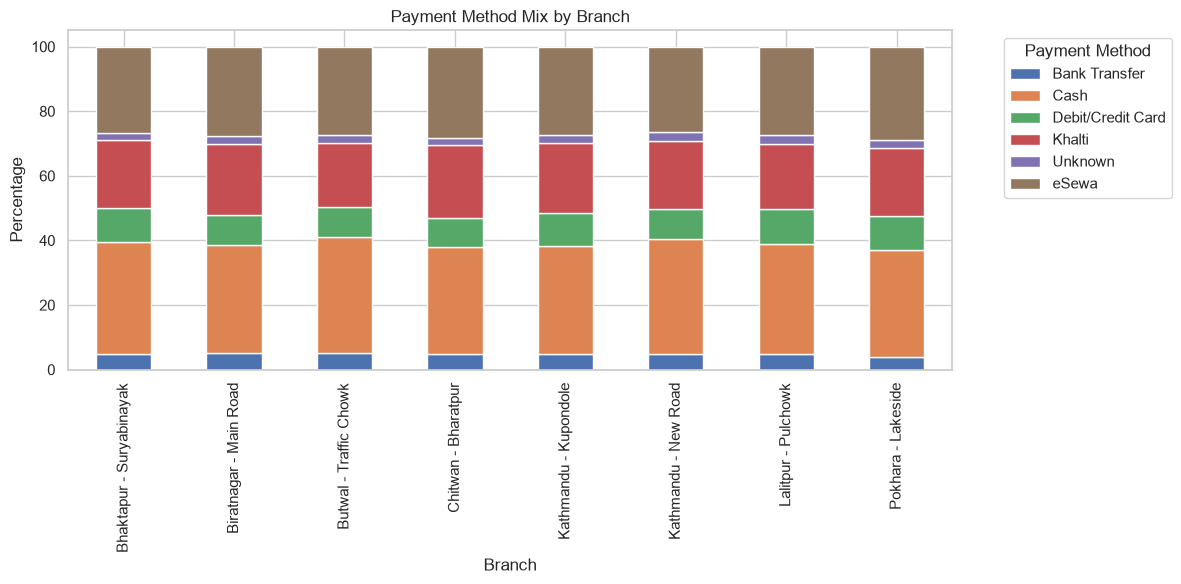

In [39]:
payment_branch = pd.crosstab(
    df_clean["Branch"],
    df_clean["PaymentMethod"],
    normalize="index"
) * 100

print(payment_branch.round(2))

payment_branch.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Payment Method Mix by Branch")
plt.xlabel("Branch")
plt.ylabel("Percentage")
plt.legend(title="Payment Method", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Q14b. Average transaction value across payment methods

In [40]:
payment_average = (
    df_clean.groupby("PaymentMethod")["TotalAmount"]
    .mean()
    .sort_values(ascending=False)
)

print(payment_average)


PaymentMethod
Unknown              1918.796571
Khalti               1881.365852
Bank Transfer        1849.672328
Debit/Credit Card    1819.482477
eSewa                1815.580287
Cash                 1788.442895
Name: TotalAmount, dtype: float64


# Part K : Correlation & Outlier Detection

## Q15a. Correlation between `Quantity`, `UnitPrice`, and `TotalAmount`

             Quantity  UnitPrice  TotalAmount
Quantity     1.000000  -0.005469     0.360532
UnitPrice   -0.005469   1.000000     0.848195
TotalAmount  0.360532   0.848195     1.000000


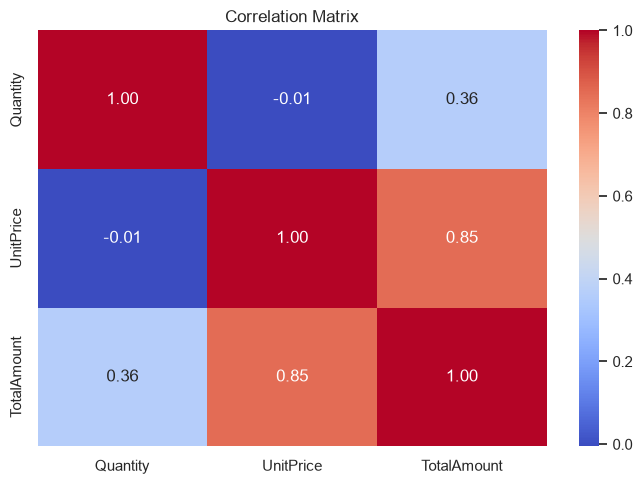

In [41]:
correlation_matrix = df_clean[
    ["Quantity", "UnitPrice", "TotalAmount"]
].corr()

print(correlation_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## Q15b. Detect outlier transactions using IQR

In [42]:
q1 = df_clean["TotalAmount"].quantile(0.25)
q3 = df_clean["TotalAmount"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df_clean[
    (df_clean["TotalAmount"] < lower_bound) |
    (df_clean["TotalAmount"] > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outlier transactions:", len(outliers))

outliers.head()


Q1: 488.595
Q3: 2152.6
IQR: 1664.0049999999999
Lower bound: -2007.4124999999997
Upper bound: 4648.6075
Number of outlier transactions: 1763


,TransactionID,Date,CustomerID,CustomerName,Branch,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod,Year,Month,MonthName,Day,DayOfWeek,IsWeekend,City,CalculatedTotalAmount,AmountDifference
2,TXN103539,2025-10-05,CUST1130,Alina Rai,Bhaktapur - Suryabinayak,Apparel,Winter Jacket,4,2794.25,11177.00,Khalti,2025,10,October,5,Sunday,True,Bhaktapur - Suryabinayak,11177.00,0.0
7,TXN104948,2025-11-01,CUST1098,Bijay Khadka,Bhaktapur - Suryabinayak,Electronics,USB Cable Type-C,4,1630.72,6522.88,Cash,2025,11,November,1,Saturday,True,Bhaktapur - Suryabinayak,6522.88,0.0
12,TXN104760,2025-09-20,CUST1052,Aashish Poudel,Lalitpur - Pulchowk,Electronics,Extension Board,3,3200.73,9602.19,Cash,2025,9,September,20,Saturday,True,Lalitpur - Pulchowk,9602.19,0.0
18,TXN100920,2025-06-22,CUST1088,Deepak Lama,Kathmandu - Kupondole,Electronics,USB Cable Type-C,3,1701.43,5104.29,Cash,2025,6,June,22,Sunday,True,Kathmandu - Kupondole,5104.29,0.0
29,TXN102943,2025-10-05,CUST1044,Puja Magar,Butwal - Traffic Chowk,Apparel,Formal Shirt,4,1943.16,7772.64,eSewa,2025,10,October,5,Sunday,True,Butwal - Traffic Chowk,7772.64,0.0


# Part L : Predictive Modeling

## Q16a. Predict `TotalAmount` from Quantity, UnitPrice, Branch, and ProductCategory

In [43]:
model_data = df_clean[
    ["Quantity", "UnitPrice", "Branch", "ProductCategory", "TotalAmount"]
].dropna()

X = model_data[
    ["Quantity", "UnitPrice", "Branch", "ProductCategory"]
]

y = model_data["TotalAmount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = ["Quantity", "UnitPrice"]
categorical_features = ["Branch", "ProductCategory"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R-squared:", round(r2, 4))


MAE: 1.13
RMSE: 2.8
R-squared: 1.0


## Q16b. Which features matter most?

In [44]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importance_values = model.named_steps["regressor"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    })
    .sort_values("Importance", ascending=False)
)

print(feature_importance.head(15))


                                         Feature    Importance
1                             numeric__UnitPrice  7.450318e-01
0                              numeric__Quantity  2.549652e-01
4     categorical__Branch_Butwal - Traffic Chowk  5.749804e-07
6      categorical__Branch_Kathmandu - Kupondole  4.312076e-07
7       categorical__Branch_Kathmandu - New Road  3.254646e-07
2   categorical__Branch_Bhaktapur - Suryabinayak  3.106732e-07
8        categorical__Branch_Lalitpur - Pulchowk  2.901647e-07
9         categorical__Branch_Pokhara - Lakeside  2.445097e-07
10          categorical__ProductCategory_Apparel  2.440866e-07
14      categorical__ProductCategory_Electronics  2.114545e-07
3     categorical__Branch_Biratnagar - Main Road  1.436985e-07
5        categorical__Branch_Chitwan - Bharatpur  1.354654e-07
16        categorical__ProductCategory_Household  2.881950e-08
15          categorical__ProductCategory_Grocery  1.433841e-08
17    categorical__ProductCategory_Personal Care  5.298

# Part M : Business Insights & Recommendations

## Q17. Management Insights

In [45]:
highest_branch = branch_revenue.idxmax()
highest_city = city_revenue.idxmax()
highest_category_revenue = category_revenue.idxmax()
highest_category_transactions = category_transaction_count.idxmax()
highest_payment = payment_counts.idxmax()
highest_day = day_revenue.idxmax()

print("BUSINESS INSIGHTS AND RECOMMENDATIONS")
print("=" * 50)

print(f"1. The highest-revenue branch is {highest_branch}.")
print(f"2. The city contributing the most revenue is {highest_city}.")
print(f"3. {highest_category_revenue} generates the highest category revenue.")
print(f"4. {highest_category_transactions} has the highest number of transactions.")
print(f"5. The most commonly used payment method is {highest_payment}.")
print(f"6. {highest_day} generates the highest total revenue.")

print("\nRECOMMENDATIONS")
print("-" * 50)
print("• Focus inventory planning on high-revenue product categories and products.")
print("• Use branch-level sales performance to improve stock allocation.")
print("• Monitor high-value and outlier transactions for unusual purchasing patterns.")
print("• Encourage digital payment adoption where branches remain heavily cash-dependent.")
print("• Use repeat-customer behavior to design customer retention and loyalty strategies.")
print("• Review missing-value and duplicate handling as part of regular data-quality monitoring.")


BUSINESS INSIGHTS AND RECOMMENDATIONS
1. The highest-revenue branch is Kathmandu - Kupondole.
2. The city contributing the most revenue is Kathmandu - Kupondole.
3. Electronics generates the highest category revenue.
4. Grocery has the highest number of transactions.
5. The most commonly used payment method is Cash.
6. Thursday generates the highest total revenue.

RECOMMENDATIONS
--------------------------------------------------
• Focus inventory planning on high-revenue product categories and products.
• Use branch-level sales performance to improve stock allocation.
• Monitor high-value and outlier transactions for unusual purchasing patterns.
• Encourage digital payment adoption where branches remain heavily cash-dependent.
• Use repeat-customer behavior to design customer retention and loyalty strategies.
• Review missing-value and duplicate handling as part of regular data-quality monitoring.


## **Data Quality Summary**

The raw data was reviewed for missing values, exact duplicate rows, repeated transaction IDs, and inconsistencies between `Quantity × UnitPrice` and `TotalAmount`.

### Cleaning Decisions
- Exact duplicate rows were removed while preserving one copy.
- Repeated `TransactionID` values were retained when they represented different line-items.
- Missing `CustomerName` values were labeled `Unknown Customer`.
- Missing `ProductCategory` values were inferred from matching product names where possible.
- Missing `UnitPrice` values were calculated from `TotalAmount / Quantity` where possible, followed by category median imputation.
- Missing `PaymentMethod` values were labeled `Unknown` instead of dropping transactions.
- `Date` was converted to datetime.
- `City` was extracted from `Branch`.
- `TotalAmount` was validated against calculated transaction amounts.
